# Experiment 02 — Feature Scaling (2 → 4 → 6 → 8 Features)

**Research question:** Does increasing feature dimensionality improve VQC classification performance?

**Setup:** For each feature count, we run the same VQC architecture with 2 layers.
Additional qubits are added as features increase.  
Features are selected by **correlation with label** (descending), filtered for low inter-feature correlation.

### HIGGS feature ranking (by |corr| with label)
| Rank | Col | Feature | |
|------|-----|---------|---|
| 1 | 26 | m_bb | high-level |
| 2 | 4  | missing energy mag. | low-level |
| 3 | 28 | m_wwbb | high-level |
| 4 | 1  | lepton pT | low-level |
| 5 | 6  | jet 1 pt | low-level |
| 6 | 13 | jet 2 b-tag | low-level |
| 7 | 27 | m_wbb | high-level |
| 8 | 25 | m_jlv | high-level |

In [5]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as pnp
from sklearn.metrics import roc_auc_score

from utils.data_utils import load_higgs, binary_accuracy, HIGGS_FEATURE_RANKING

np.random.seed(42)

In [6]:
# Hyperparameters (held constant across all experiments)
N_LAYERS   = 2
N_EPOCHS   = 30
BATCH_SIZE = 32
LR         = 0.01
N_SAMPLES  = 5000

# Feature sets: top-N from correlation-ranked features
# [26, 4, 28, 1, 6, 13, 27, 25]
FEATURE_SETS = {
    2: HIGGS_FEATURE_RANKING[:2],   # [26, 4]
    4: HIGGS_FEATURE_RANKING[:4],   # [26, 4, 28, 1]
    6: HIGGS_FEATURE_RANKING[:6],   # [26, 4, 28, 1, 6, 13]
    8: HIGGS_FEATURE_RANKING[:8],   # [26, 4, 28, 1, 6, 13, 27, 25]
}

print('Feature sets:', FEATURE_SETS)

Feature sets: {2: [26, 4], 4: [26, 4, 28, 1], 6: [26, 4, 28, 1, 6, 13], 8: [26, 4, 28, 1, 6, 13, 27, 25]}


In [7]:
def build_circuit(n_features, n_layers):
    """Build and return a VQC circuit for n_features qubits."""
    dev = qml.device('default.qubit', wires=n_features)

    @qml.qnode(dev, interface='autograd')
    def circuit(weights, x):
        # State preparation
        for i in range(n_features):
            qml.RY(x[i], wires=i)
        # Model circuit
        for l in range(n_layers):
            for q in range(n_features):
                qml.Rot(weights[l, q, 0], weights[l, q, 1], weights[l, q, 2], wires=q)
            for q in range(n_features - 1):
                qml.CNOT(wires=[q, q + 1])
            if n_features > 1:
                qml.CNOT(wires=[n_features - 1, 0])
        return qml.expval(qml.PauliZ(0))

    return circuit


def train_vqc(circuit_fn, X_train, y_train, X_val, y_val,
              n_layers, n_features, n_epochs, batch_size, lr):
    weights = pnp.array(
        np.random.uniform(0, 2*np.pi, (n_layers, n_features, 3)),
        requires_grad=True
    )
    bias = pnp.array(0.0, requires_grad=True)
    opt = qml.AdamOptimizer(stepsize=lr)

    train_losses, val_losses = [], []

    for epoch in range(n_epochs):
        perm = np.random.permutation(len(X_train))
        Xs, ys = X_train[perm], y_train[perm]

        for start in range(0, len(X_train), batch_size):
            Xb = Xs[start:start+batch_size]
            yb = ys[start:start+batch_size].astype(float)

            def cost(w, b):
                preds = pnp.array([circuit_fn(w, x) + b for x in Xb])
                return pnp.mean((yb - preds) ** 2)

            weights, bias = opt.step(cost, weights, bias)

        # Epoch-level metrics
        tr_preds = pnp.array([circuit_fn(weights, x) + bias for x in X_train])
        vl_preds = pnp.array([circuit_fn(weights, x) + bias for x in X_val])
        tr_loss = float(pnp.mean((y_train.astype(float) - tr_preds)**2))
        vl_loss = float(pnp.mean((y_val.astype(float) - vl_preds)**2))
        train_losses.append(tr_loss)
        val_losses.append(vl_loss)

        if (epoch+1) % 10 == 0 or epoch == 0:
            print(f'  Epoch {epoch+1}/{n_epochs} | train_loss={tr_loss:.4f}, val_loss={vl_loss:.4f}')

    return weights, bias, train_losses, val_losses

## Run experiments

In [8]:
results = {}

for n_feat, feat_cols in FEATURE_SETS.items():
    print(f'\n{"="*50}')
    print(f'Running: {n_feat} features, columns={feat_cols}')

    X_train, X_val, X_test, y_train, y_val, y_test = load_higgs(
        path='../data/HIGGS.csv.gz',
        n_samples=N_SAMPLES,
        feature_indices=feat_cols,
        scale_range=(0, np.pi),
    )

    circuit_fn = build_circuit(n_feat, N_LAYERS)

    np.random.seed(42)
    weights, bias, tr_loss, vl_loss = train_vqc(
        circuit_fn, X_train, y_train, X_val, y_val,
        N_LAYERS, n_feat, N_EPOCHS, BATCH_SIZE, LR
    )

    # Final evaluation on test set
    test_raw = np.array([float(circuit_fn(weights, x) + bias) for x in X_test])
    test_acc = binary_accuracy(y_test, test_raw)
    y_test_01 = (y_test == 1).astype(int)
    test_score = (test_raw - test_raw.min()) / (test_raw.max() - test_raw.min() + 1e-8)
    test_auc = roc_auc_score(y_test_01, test_score)

    results[n_feat] = {
        'train_losses': tr_loss,
        'val_losses': vl_loss,
        'test_acc': test_acc,
        'test_auc': test_auc,
        'n_params': N_LAYERS * n_feat * 3 + 1,
    }
    print(f'  → Test acc: {test_acc:.4f} | Test AUC: {test_auc:.4f} | Params: {results[n_feat]["n_params"]}')


Running: 2 features, columns=[26, 4]
Selected features (cols [26, 4]): ['m_bb', 'missing energy mag.']
Dataset: 5000 samples | 2 features | train=3000, val=1000, test=1000
  Epoch 1/30 | train_loss=0.9669, val_loss=0.9665
  Epoch 10/30 | train_loss=0.9522, val_loss=0.9529
  Epoch 20/30 | train_loss=0.9499, val_loss=0.9525
  Epoch 30/30 | train_loss=0.9496, val_loss=0.9526
  → Test acc: 0.6160 | Test AUC: 0.6087 | Params: 13

Running: 4 features, columns=[26, 4, 28, 1]
Selected features (cols [26, 4, 28, 1]): ['m_bb', 'missing energy mag.', 'm_wwbb', 'lepton pT']
Dataset: 5000 samples | 4 features | train=3000, val=1000, test=1000
  Epoch 1/30 | train_loss=0.9869, val_loss=0.9855
  Epoch 10/30 | train_loss=0.9466, val_loss=0.9579
  Epoch 20/30 | train_loss=0.9420, val_loss=0.9551
  Epoch 30/30 | train_loss=0.9370, val_loss=0.9477
  → Test acc: 0.6080 | Test AUC: 0.6128 | Params: 25

Running: 6 features, columns=[26, 4, 28, 1, 6, 13]
Selected features (cols [26, 4, 28, 1, 6, 13]): ['m_b

In [9]:
# --- Summary table ---
print('\nFeature Scaling Results')
print(f'{"Features":>10} {"Params":>8} {"Test Acc":>10} {"Test AUC":>10}')
print('-' * 42)
for nf, r in results.items():
    print(f'{nf:>10} {r["n_params"]:>8} {r["test_acc"]:>10.4f} {r["test_auc"]:>10.4f}')


Feature Scaling Results
  Features   Params   Test Acc   Test AUC
------------------------------------------
         2       13     0.6160     0.6087
         4       25     0.6080     0.6128
         6       37     0.6160     0.6728
         8       49     0.6150     0.6769


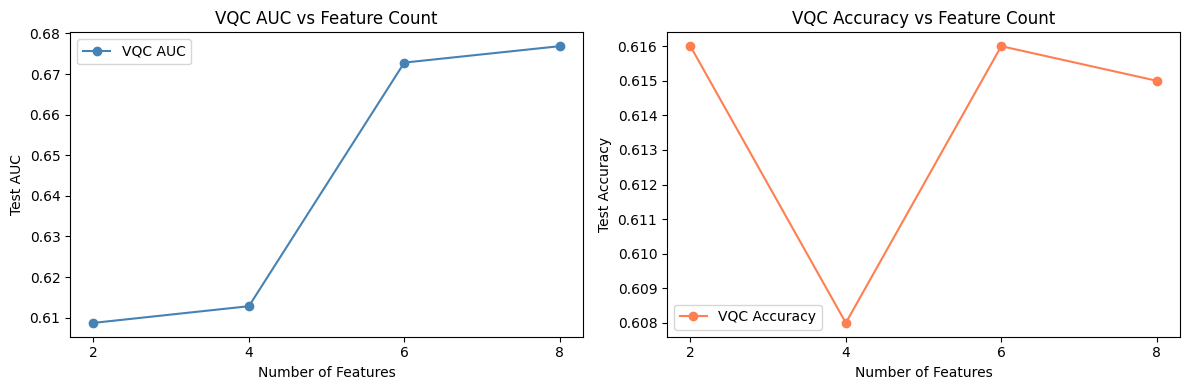

In [10]:
# --- Plot: AUC vs number of features ---
feat_counts = list(results.keys())
aucs = [results[f]['test_auc'] for f in feat_counts]
accs = [results[f]['test_acc'] for f in feat_counts]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(feat_counts, aucs, 'o-', color='steelblue', label='VQC AUC')
axes[0].set_xlabel('Number of Features')
axes[0].set_ylabel('Test AUC')
axes[0].set_title('VQC AUC vs Feature Count')
axes[0].set_xticks(feat_counts)
axes[0].legend()

axes[1].plot(feat_counts, accs, 'o-', color='coral', label='VQC Accuracy')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('VQC Accuracy vs Feature Count')
axes[1].set_xticks(feat_counts)
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/02_feature_scaling.png', dpi=150)
plt.show()

## Observations

*(Fill in after running)*

- Does AUC increase monotonically with features?
- Is there a point of diminishing returns or degradation (barren plateau)?
- How does the VQC compare to the classical MLP at each feature count?